# Sentiment Analysis of Financial News Headlines
## This task tests your ability to apply NLP techniques you've learnt to classify a news headline containing financial information into either one of the sentiments (Positive, Negative or Neutral)

### Dataset:
https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv

## Max Marks without Bonus attempted: 80 points
## Max Marks with Bonus: 100 points
- ### Bonus: 20 points

### Steps
- 1. Download the dataset
- 2. Load the dataset
- 3. Explore the dataset (Exploratory Data Analysis)
- 4. Clean the data
- 5. Apply SMOTE for imbalanced data [Optional] --> Carries Bonus Marks
- 6. Build a BoW model
- 7. Build a Tf-Idf model
- 8. Split train and test data
- 9. Use one ML Classifying algorithm to classify the finanical news headline data
- 10. Use another ML classifying algorithm to classify them
- 11. Plot Confusion matrix 

In [3]:
!pip install imblearn

## 1. Download the dataset [1 point]

In [21]:
import pandas as pd

url = "https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv"

## 2. Load the dataset [1 point]

In [24]:
# Specify an alternative encoding (e.g., 'latin1')
df = pd.read_csv(url, header=None, names=["sentiment", "headline"], encoding='latin1')

## 3. Explore the dataset [10 points]

In [27]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData types:\n", df.dtypes)

Shape of dataset: (4846, 2)

First 5 rows:
   sentiment                                           headline
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...

Data types:
 sentiment    object
headline     object
dtype: object


In [29]:
print(df.head())
print(df.columns)

  sentiment                                           headline
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...
Index(['sentiment', 'headline'], dtype='object')


## 4. Clean the data [5 points]

In [31]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['headline'].astype(str).apply(preprocess)

# 檢查前幾筆清理後的資料
print(df[['headline', 'cleaned']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wayne\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                            headline  \
0  According to Gran , the company has no plans t...   
1  Technopolis plans to develop in stages an area...   
2  The international electronic industry company ...   
3  With the new production plant the company woul...   
4  According to the company 's updated strategy f...   

                                             cleaned  
0  according gran company plan move production ru...  
1  technopolis plan develop stage area less squar...  
2  international electronic industry company elco...  
3  new production plant company would increase ca...  
4  according company updated strategy year baswar...  


## 5. SMOTE (Imbalanced dataset) [OPTIONAL] BONUS [20 points]
Hint: Use **imblearn** library

In [39]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder

X_text = df['cleaned']
y = LabelEncoder().fit_transform(df['sentiment'])  # Encode target

# Use BoW temporarily for SMOTE
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X_text)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_vec, y)

C:\Users\wayne\anaconda3\envs\GBC_Task\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 6. BoW model [15 points]

In [41]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df['cleaned'])

## 7. Tf-idf model [15 points]

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned'])


## 8. Split train test data [3 points]

In [45]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


## 9. Classification Algorithm [10 points]
- Train
- Predict

In [47]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Using Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
y_pred_nb_bow = nb.predict(X_test_bow)

nb.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb.predict(X_test_tfidf)

## 10. Another Classification Algorithm [10 points]
- Train
- Predict

In [49]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bow, y_train)
y_pred_lr_bow = lr.predict(X_test_bow)

lr.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr.predict(X_test_tfidf)

## 11. Confusion Matrixes for two classification algorithms and two feature extractor methods [10 points]

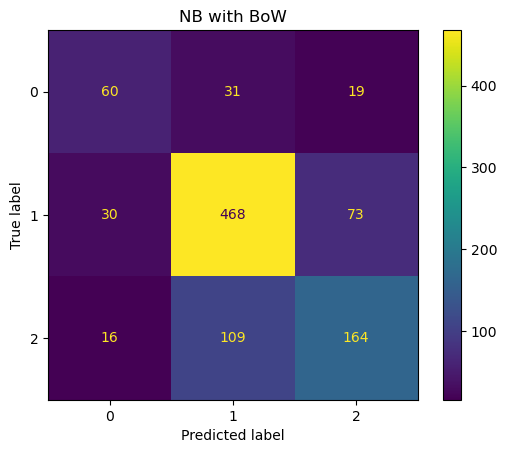

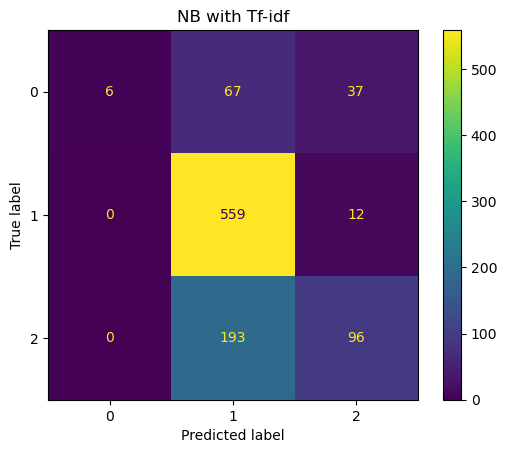

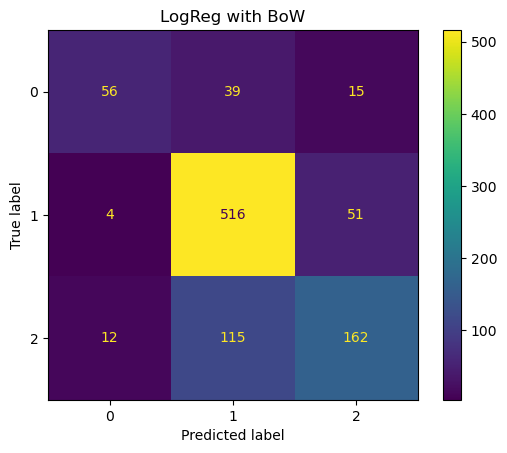

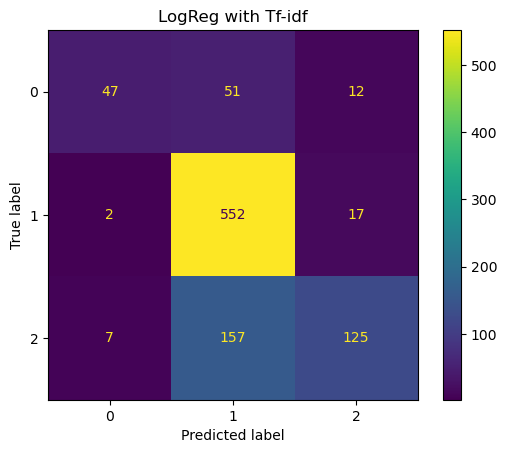

Naive Bayes (BoW):
               precision    recall  f1-score   support

           0       0.57      0.55      0.56       110
           1       0.77      0.82      0.79       571
           2       0.64      0.57      0.60       289

    accuracy                           0.71       970
   macro avg       0.66      0.64      0.65       970
weighted avg       0.71      0.71      0.71       970

Naive Bayes (Tf-idf):
               precision    recall  f1-score   support

           0       1.00      0.05      0.10       110
           1       0.68      0.98      0.80       571
           2       0.66      0.33      0.44       289

    accuracy                           0.68       970
   macro avg       0.78      0.46      0.45       970
weighted avg       0.71      0.68      0.62       970

Logistic Regression (BoW):
               precision    recall  f1-score   support

           0       0.78      0.51      0.62       110
           1       0.77      0.90      0.83       571
    

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns



def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

plot_cm(y_test, y_pred_nb_bow, "NB with BoW")
plot_cm(y_test, y_pred_nb_tfidf, "NB with Tf-idf")
plot_cm(y_test, y_pred_lr_bow, "LogReg with BoW")
plot_cm(y_test, y_pred_lr_tfidf, "LogReg with Tf-idf")

# Bonus: Classification reports
print("Naive Bayes (BoW):\n", classification_report(y_test, y_pred_nb_bow))
print("Naive Bayes (Tf-idf):\n", classification_report(y_test, y_pred_nb_tfidf))
print("Logistic Regression (BoW):\n", classification_report(y_test, y_pred_lr_bow))
print("Logistic Regression (Tf-idf):\n", classification_report(y_test, y_pred_lr_tfidf))